In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import librosa

from datasets import load_dataset, Audio

print("VAD projesi başarıyla başlatıldı!")

In [ ]:
dataset = load_dataset(
    "guynich/librispeech_asr_test_vad",
    split="test.clean",
    streaming=True
)

dataset = dataset.cast_column(
    "audio",
    Audio(decode=False)
)

sample = next(iter(dataset))

print("Veri alanları:", sample.keys())
print("Dosya:", sample["file"])
print("Metin:", sample["text"])

In [3]:
import io
import soundfile as sf

audio_data = sample["audio"]

if audio_data["bytes"] is not None:
    y, sr = sf.read(io.BytesIO(audio_data["bytes"]))
else:
    y, sr = sf.read(audio_data["path"])

# Ses stereo ise mono hâline getir.
if y.ndim > 1:
    y = y.mean(axis=1)

print("Örnekleme frekansı:", sr, "Hz")
print("Toplam örnek sayısı:", len(y))
print("Ses süresi:", round(len(y) / sr, 2), "saniye")

Örnekleme frekansı: 16000 Hz
Toplam örnek sayısı: 56080
Ses süresi: 3.5 saniye


In [4]:
from IPython.display import Audio, display

display(Audio(y, rate=sr))

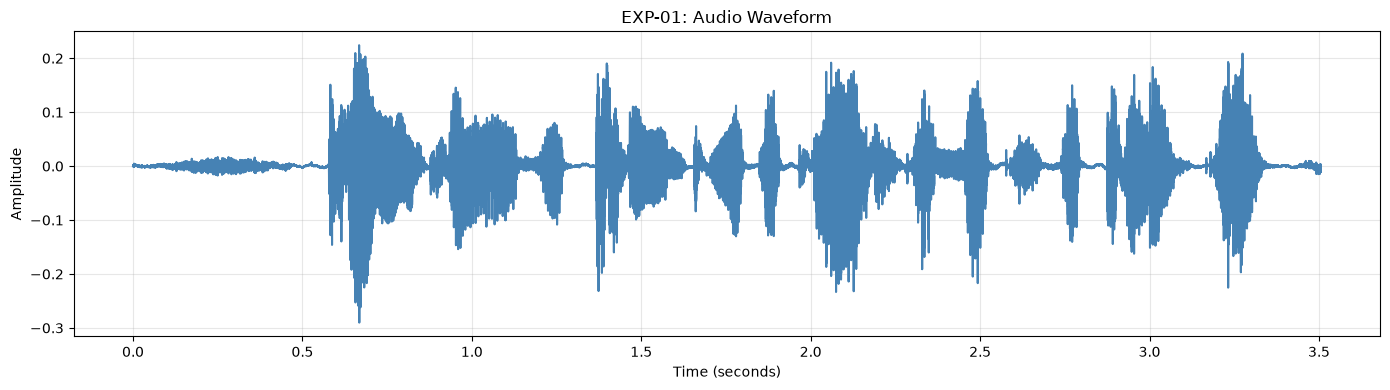

In [5]:
time = np.arange(len(y)) / sr

plt.figure(figsize=(14, 4))

plt.plot(time, y, color="steelblue")

plt.title("EXP-01: Audio Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# Frame parametreleri
frame_ms = 25
hop_ms = 10

frame_length = int(sr * frame_ms / 1000)
hop_length = int(sr * hop_ms / 1000)

# RMS Energy hesaplama
rms = librosa.feature.rms(
    y=y,
    frame_length=frame_length,
    hop_length=hop_length,
    center=False
)[0]

# Her frame'in orta noktasının zamanı
rms_times = (
    np.arange(len(rms)) * hop_length + frame_length / 2
) / sr

print("Frame uzunluğu:", frame_length, "örnek")
print("Hop uzunluğu:", hop_length, "örnek")
print("Toplam frame sayısı:", len(rms))

Frame uzunluğu: 400 örnek
Hop uzunluğu: 160 örnek
Toplam frame sayısı: 349


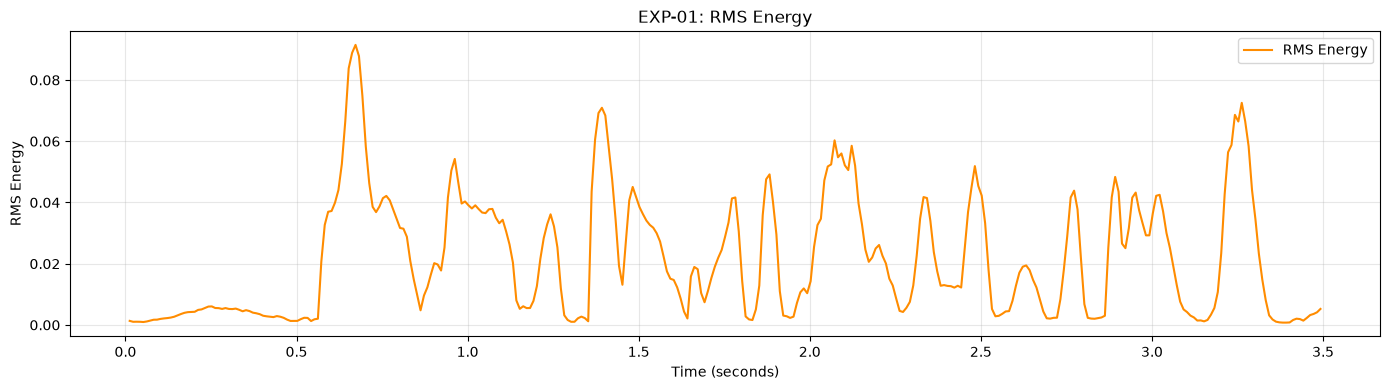

In [7]:
plt.figure(figsize=(14, 4))

plt.plot(
    rms_times,
    rms,
    color="darkorange",
    label="RMS Energy"
)

plt.title("EXP-01: RMS Energy")
plt.xlabel("Time (seconds)")
plt.ylabel("RMS Energy")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

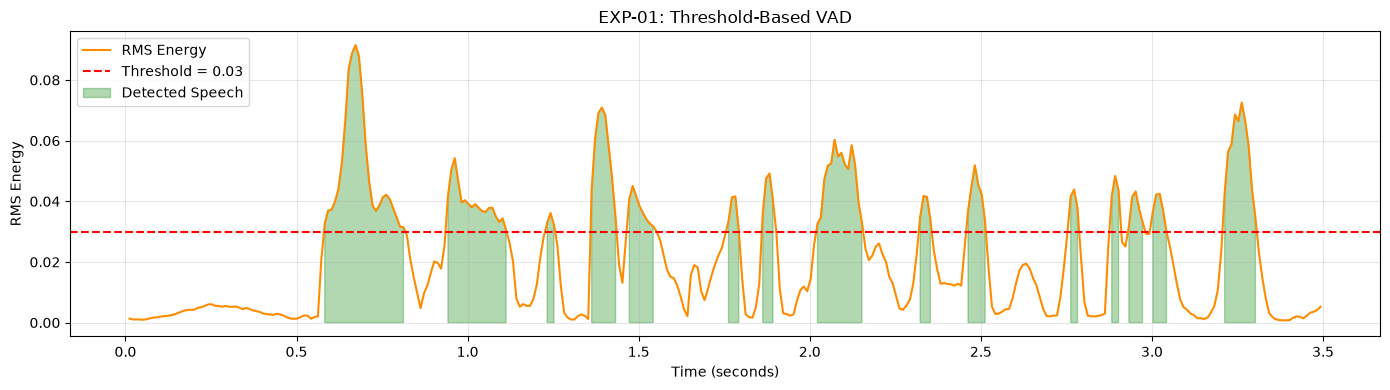

Konuşma olarak sınıflandırılan frame: 119
Toplam frame: 349


In [8]:
threshold = 0.03

vad_prediction = (rms > threshold).astype(int)

plt.figure(figsize=(14, 4))

plt.plot(
    rms_times,
    rms,
    color="darkorange",
    label="RMS Energy"
)

plt.axhline(
    y=threshold,
    color="red",
    linestyle="--",
    label=f"Threshold = {threshold}"
)

plt.fill_between(
    rms_times,
    0,
    rms,
    where=vad_prediction == 1,
    color="green",
    alpha=0.3,
    label="Detected Speech"
)

plt.title("EXP-01: Threshold-Based VAD")
plt.xlabel("Time (seconds)")
plt.ylabel("RMS Energy")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Konuşma olarak sınıflandırılan frame:", vad_prediction.sum())
print("Toplam frame:", len(vad_prediction))

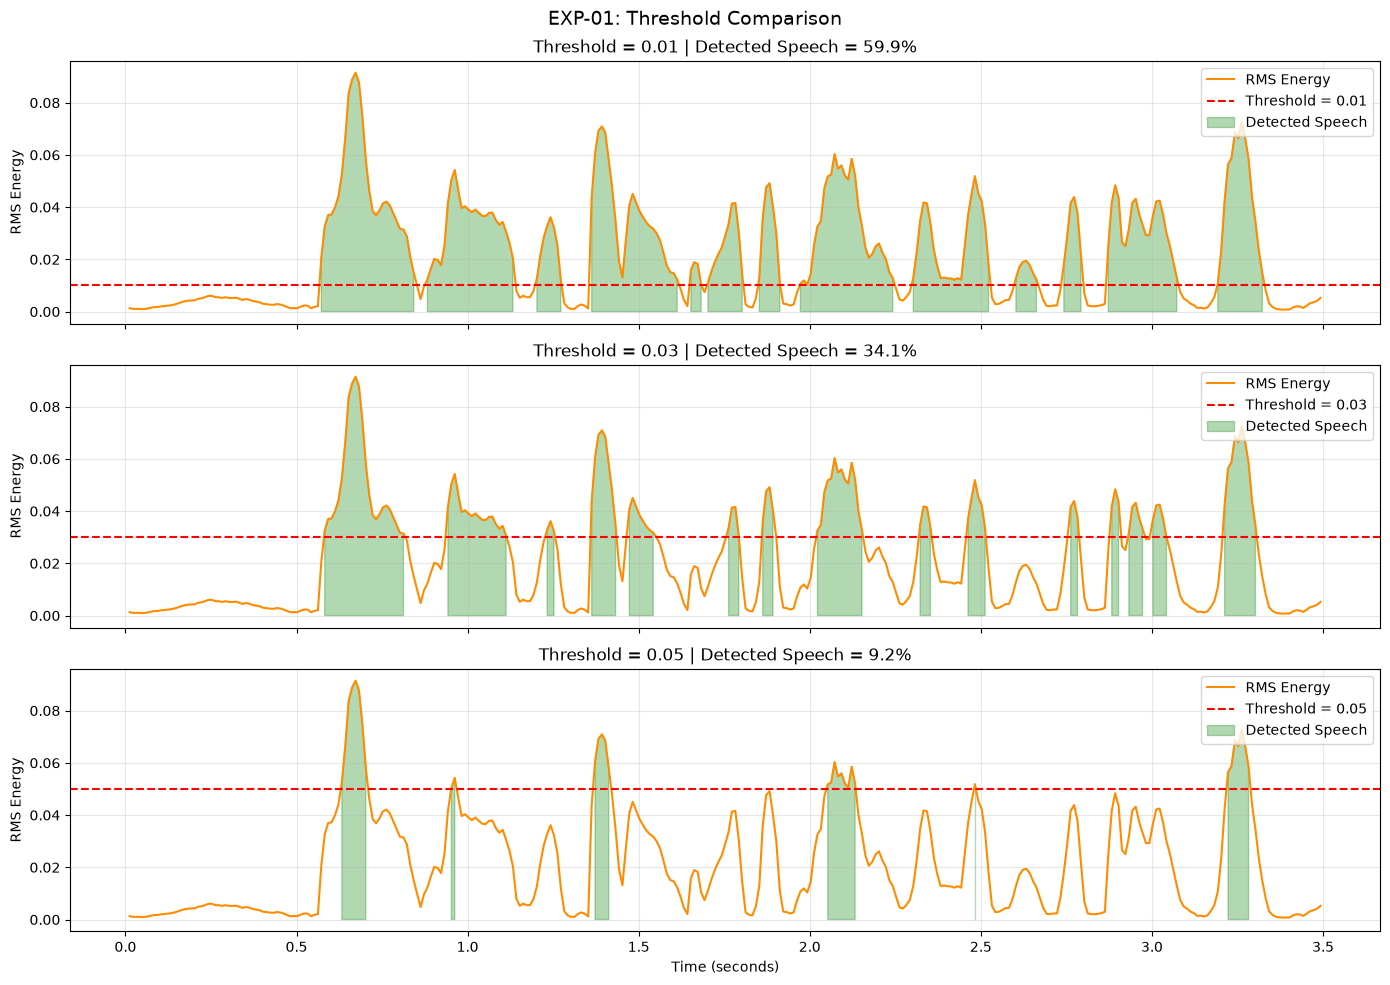

In [9]:
thresholds = [0.01, 0.03, 0.05]

fig, axes = plt.subplots(
    3, 1,
    figsize=(14, 10),
    sharex=True
)

for ax, threshold in zip(axes, thresholds):

    prediction = (rms > threshold).astype(int)

    ax.plot(
        rms_times,
        rms,
        color="darkorange",
        label="RMS Energy"
    )

    ax.axhline(
        threshold,
        color="red",
        linestyle="--",
        label=f"Threshold = {threshold}"
    )

    ax.fill_between(
        rms_times,
        0,
        rms,
        where=prediction == 1,
        color="green",
        alpha=0.3,
        label="Detected Speech"
    )

    speech_ratio = prediction.mean() * 100

    ax.set_title(
        f"Threshold = {threshold} | "
        f"Detected Speech = {speech_ratio:.1f}%"
    )

    ax.set_ylabel("RMS Energy")
    ax.legend(loc="upper right")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time (seconds)")

plt.suptitle(
    "EXP-01: Threshold Comparison",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [10]:
print("Speech veri türü:", type(sample["speech"]))
print("Confidence veri türü:", type(sample["confidence"]))

print("\nSpeech değeri:")
print(str(sample["speech"])[:1000])

print("\nConfidence değeri:")
print(str(sample["confidence"])[:1000])

print("\nRMS frame sayısı:", len(rms))
print("Ses süresi:", len(y) / sr)

Speech veri türü: <class 'list'>
Confidence veri türü: <class 'list'>

Speech değeri:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0]

Confidence değeri:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1]

RMS frame sayısı: 349
Ses süresi: 3.505


In [11]:
import numpy as np

reference = np.asarray(sample["speech"], dtype=int)
confidence = np.asarray(sample["confidence"], dtype=int)

print("Ses süresi:", round(len(y) / sr, 3), "saniye")
print("Ses örnek sayısı:", len(y))

print("\nReferans etiket sayısı:", len(reference))
print("Confidence etiket sayısı:", len(confidence))
print("Bizim RMS frame sayımız:", len(rms))

print("\nReferanstaki konuşma sayısı:", np.sum(reference == 1))
print("Referanstaki konuşma dışı sayısı:", np.sum(reference == 0))

print("\nGüvenilir işaretlenen etiket sayısı:", np.sum(confidence == 1))
print("Belirsiz işaretlenen etiket sayısı:", np.sum(confidence == 0))

print("\nEtiket başına ortalama süre (ms):",
      round((len(y) / sr) / len(reference) * 1000, 2))

Ses süresi: 3.505 saniye
Ses örnek sayısı: 56080

Referans etiket sayısı: 109
Confidence etiket sayısı: 109
Bizim RMS frame sayımız: 349

Referanstaki konuşma sayısı: 82
Referanstaki konuşma dışı sayısı: 27

Güvenilir işaretlenen etiket sayısı: 101
Belirsiz işaretlenen etiket sayısı: 8

Etiket başına ortalama süre (ms): 32.16


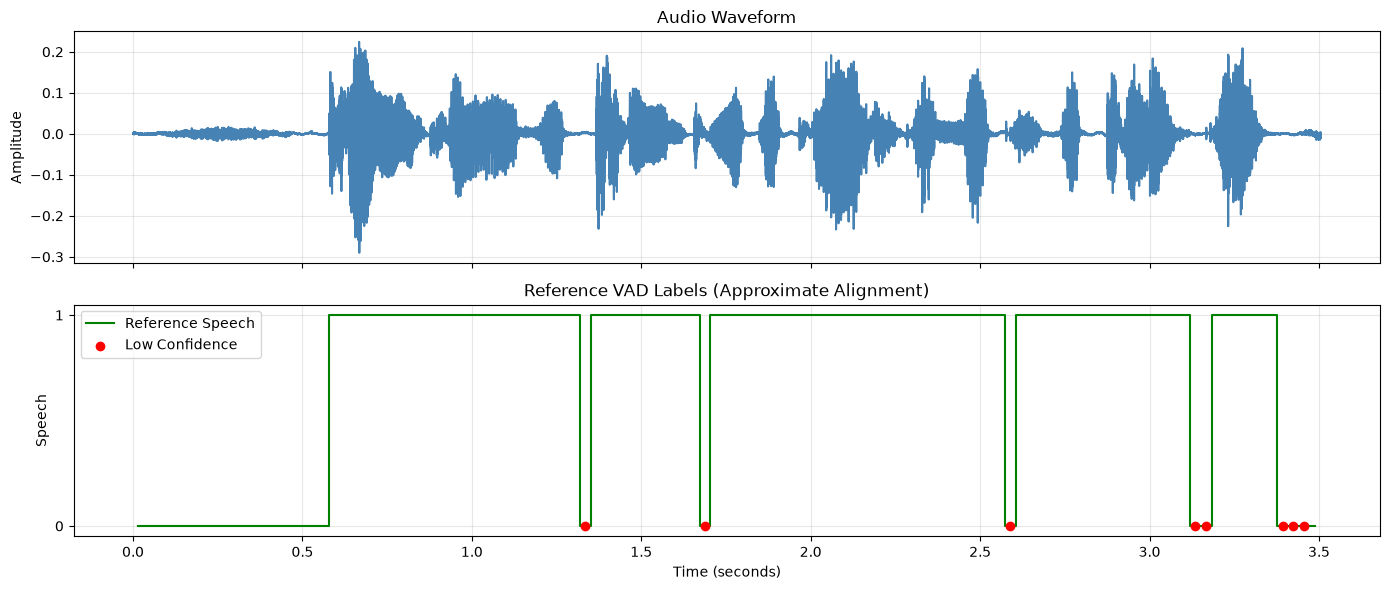

In [12]:
reference = np.asarray(sample["speech"], dtype=int)
confidence = np.asarray(sample["confidence"], dtype=int)

duration = len(y) / sr

# Yalnızca keşif amaçlı yaklaşık zaman ekseni
reference_times = (
    np.arange(len(reference)) + 0.5
) * duration / len(reference)

fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 6),
    sharex=True
)

axes[0].plot(
    np.arange(len(y)) / sr,
    y,
    color="steelblue"
)

axes[0].set_title("Audio Waveform")
axes[0].set_ylabel("Amplitude")
axes[0].grid(alpha=0.3)

axes[1].step(
    reference_times,
    reference,
    where="mid",
    color="green",
    label="Reference Speech"
)

axes[1].scatter(
    reference_times[confidence == 0],
    reference[confidence == 0],
    color="red",
    label="Low Confidence",
    zorder=3
)

axes[1].set_title("Reference VAD Labels (Approximate Alignment)")
axes[1].set_xlabel("Time (seconds)")
axes[1].set_ylabel("Speech")
axes[1].set_yticks([0, 1])
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
print("Ses süresi:", len(y) / sr)

print("Referans etiket sayısı:", len(reference))

print("32 ms üzerinden beklenen etiket sayısı:",
      int(np.ceil((len(y) / sr) / 0.032)))

print("Referans etiket başına ortalama süre:",
      (len(y) / sr) / len(reference) * 1000,
      "ms")

print("İlk 20 referans etiketi:", reference[:20])
print("Son 20 referans etiketi:", reference[-20:])

Ses süresi: 3.505
Referans etiket sayısı: 109
32 ms üzerinden beklenen etiket sayısı: 110
Referans etiket başına ortalama süre: 32.15596330275229 ms
İlk 20 referans etiketi: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1]
Son 20 referans etiketi: [1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 0 0 0]


In [14]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

# Referans etiketlerin yaklaşık orta noktaları
reference_times = (
    np.arange(len(reference)) + 0.5
) * (len(y) / sr) / len(reference)

# Her referans zamanına en yakın RMS frame'ini bul
indices = np.abs(
    rms_times[:, None] - reference_times[None, :]
).argmin(axis=0)

# Yalnızca confidence=1 olan etiketleri değerlendir
valid = confidence == 1

thresholds = [0.01, 0.03, 0.05]

for threshold in thresholds:

    prediction = (rms > threshold).astype(int)

    # Tahminleri referans zamanlarına eşleştir
    aligned_prediction = prediction[indices]

    y_true = reference[valid]
    y_pred = aligned_prediction[valid]

    precision = precision_score(
        y_true, y_pred, zero_division=0
    )

    recall = recall_score(
        y_true, y_pred, zero_division=0
    )

    f1 = f1_score(
        y_true, y_pred, zero_division=0
    )

    accuracy = accuracy_score(y_true, y_pred)

    print(f"\nThreshold: {threshold}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1-score:  {f1:.3f}")
    print(f"Accuracy:  {accuracy:.3f}")


Threshold: 0.01
Precision: 1.000
Recall:    0.805
F1-score:  0.892
Accuracy:  0.842

Threshold: 0.03
Precision: 1.000
Recall:    0.451
F1-score:  0.622
Accuracy:  0.554

Threshold: 0.05
Precision: 1.000
Recall:    0.098
F1-score:  0.178
Accuracy:  0.267


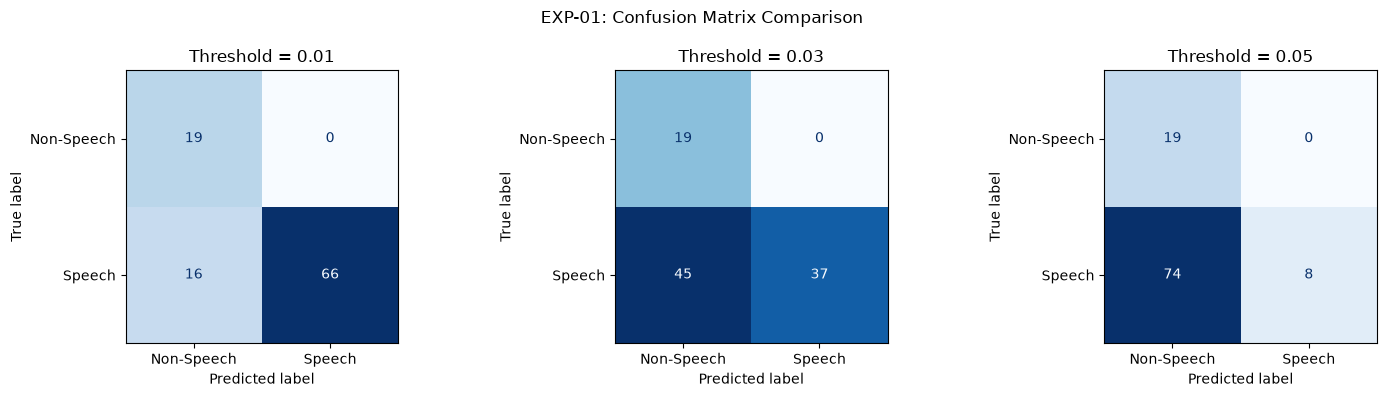

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, threshold in zip(axes, thresholds):

    prediction = (rms > threshold).astype(int)
    aligned_prediction = prediction[indices]

    y_true = reference[valid]
    y_pred = aligned_prediction[valid]

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-Speech", "Speech"]
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        values_format="d"
    )

    ax.set_title(f"Threshold = {threshold}")

plt.suptitle("EXP-01: Confusion Matrix Comparison")
plt.tight_layout()
plt.show()